In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import statistics


def set_size(fraction_width=0.95, fraction_height=0.25):
    width_pt = 241.14749 # column width in pt
    height_pt = 626.0 # page height in pt

    fig_width_pt = width_pt * fraction_width
    fig_height_pt = height_pt * fraction_height
    inches_per_pt = 1 / 72.27

    fig_width_in = fig_width_pt * inches_per_pt
    fig_height_in = fig_height_pt * inches_per_pt

    return fig_width_in, fig_height_in

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# Set default background color for the plot area (axes)
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['xtick.color'] = 'black'     
plt.rcParams['ytick.color'] = 'black'      
plt.rcParams['axes.labelcolor'] = 'black'    
plt.rcParams['axes.edgecolor'] = 'black'     
plt.rcParams['font.size'] = '12'    

def create_dict():
    return {"Execution": [], "Optimization": []}

colors = {'ResultDB_Decompose': 'blue', 'ResultDB_SemiJoin':'green', 'TD_Root': 'brown', 'TD_Fold': 'red', 'TD_Fold-Greedy': 'orange', 'TD_ResultDB': 'violet', 'DP_ResultDB_Greedy': 'violet', 'DP_ResultDB_Exhaustive': 'red'}
alg_to_latex = {'ResultDB_Decompose': r'ResultDB$_{\text{Decompose}}$', 'ResultDB_SemiJoin': r'ResultDB$_{\text{Semi-Join}}$','TD_Root': r'TD$_{\text{Root}}$', 'TD_Fold': r'TD$_{\text{Fold}}$', 'TD_Fold-Greedy': r'TD$_{\text{Fold-NoTVC}}$', 'TD_ResultDB': r'TD$_{\text{ResultDB}}$', 'DP_ResultDB_Greedy': r'DP$_{\text{ResultDB\_Greedy}}$', 'DP_ResultDB_Exhaustive': r'DP$_{\text{ResultDB\_Exhaustive}}$'}


# !!!!!!!!!!!!!!!!!!!!!!!! ATTENTION !!!!!!!!!!!!!!!!!!!!!!!!
# If you want to create the visualization for the existing results in the repository, set the parameter 'use_existing_results' to 'True',
# if you want to create the visualization for the newly results in your rerun of the experiments, set it to 'False'
use_existing_results: bool = False
# !!!!!!!!!!!!!!!!!!!!!!!! ATTENTION !!!!!!!!!!!!!!!!!!!!!!!!
result_path: str = "existing_results" if use_existing_results else "recreated_results"

# Enumeration Time Experiments

## Star Benchmarks

{'ResultDB_Decompose': [0.0155, 0.1455, 1.9655, 316.09000000000003], 'ResultDB_SemiJoin': [0.008, 0.027, 0.094, 0.039], 'TD_Root': [0.012, 0.0305, 0.104, 0.058], 'TD_ResultDB': [0.023, 0.1475, 2.068, 318.4605]}
1.5
1.1296296296296295
1.1063829787234043
1.4871794871794872


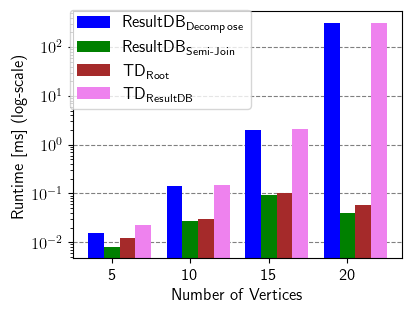

In [12]:
algorithm_times = {
    'ResultDB_Decompose': [],
    'ResultDB_SemiJoin': [],
    'TD_Root': [],
    'TD_ResultDB': []
}

sizes = [5, 10, 15, 20]
data = pd.read_csv(f'./enumeration_time/{result_path}/star.csv')
data = (data.groupby(by=['commit', 'date', 'version', 'suite', 'benchmark', 'experiment', 'name', 'config', 'case',], as_index=False)
                .median()
                .drop(['commit', 'date', 'version', 'suite', 'benchmark', 'experiment', 'runid'], axis=1)
        )
num_queries = 0
for size in sizes:
    # Get Results for each query 
    size_data = data[data['case'] == size]

    for _, row in size_data.iterrows():
        algorithm = row['name']
        execution_time = row['time']
        if "TD_Root" in algorithm:
            algorithm_times['TD_Root'].append(execution_time)
        elif "ResultDB-Heuristic" in algorithm:
            algorithm_times['ResultDB_SemiJoin'].append(execution_time)
        elif "Decompose" in algorithm:
            algorithm_times['ResultDB_Decompose'].append(execution_time)
        elif "TD_ResultDB" in algorithm:
            algorithm_times['TD_ResultDB'].append(execution_time)
            
print(algorithm_times)
x = np.arange(len(sizes))  
width = 0.2  
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(4,3))
for algorithm, time in algorithm_times.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, time, width, label=alg_to_latex[algorithm], color=colors[algorithm])
    multiplier += 1

for i in range(len(sizes)):
    print(algorithm_times['TD_Root'][i] / algorithm_times['ResultDB_SemiJoin'][i])

ax.set_ylabel('Runtime [ms] (log-scale)')
ax.set_xlabel('Number of Vertices')
ax.set_xticks(x + width, sizes)
ax.set_yscale('log')
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed')
fig.legend(bbox_to_anchor=(0.14, 1.02), loc='upper left')

fig.savefig(f'./enumeration_time/{result_path}/star_benchmark_results.pdf')


## Chain Queries

1.5
1.076923076923077
1.068421052631579
1.1395348837209303


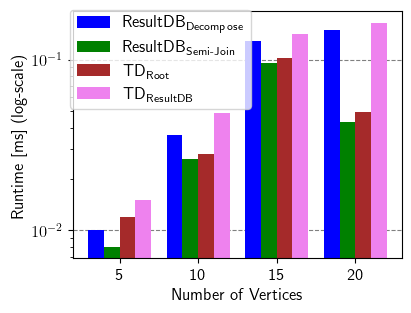

In [13]:
algorithm_times = {
    'ResultDB_Decompose': [],
    'ResultDB_SemiJoin': [],
    'TD_Root': [],
    'TD_ResultDB': []
}

sizes = [5, 10, 15, 20]
data = pd.read_csv(f'./enumeration_time/{result_path}/chain.csv')
data = (data.groupby(by=['commit', 'date', 'version', 'suite', 'benchmark', 'experiment', 'name', 'config', 'case',], as_index=False)
                .median()
                .drop(['commit', 'date', 'version', 'suite', 'benchmark', 'experiment', 'runid'], axis=1)
        )
num_queries = 0
for size in sizes:
    # Get Results for each query 
    size_data = data[data['case'] == size]

    for _, row in size_data.iterrows():
        algorithm = row['name']
        execution_time = row['time']
        if "TD_Root" in algorithm:
            algorithm_times['TD_Root'].append(execution_time)
        elif "ResultDB-Heuristic" in algorithm:
            algorithm_times['ResultDB_SemiJoin'].append(execution_time)
        elif "Decompose" in algorithm:
            algorithm_times['ResultDB_Decompose'].append(execution_time)
        elif "TD_ResultDB" in algorithm:
            algorithm_times['TD_ResultDB'].append(execution_time)
            

x = np.arange(len(sizes)) 
width = 0.2 
multiplier = -0.5
fig, ax = plt.subplots(layout='constrained', figsize=(4,3))
for algorithm, time in algorithm_times.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, time, width, label=alg_to_latex[algorithm], color=colors[algorithm])
    multiplier += 1

for i in range(len(sizes)):
    print(algorithm_times['TD_Root'][i] / algorithm_times['ResultDB_SemiJoin'][i])

ax.set_ylabel('Runtime [ms] (log-scale)')
ax.set_xlabel('Number of Vertices')
ax.set_xticks(x + width, sizes)
ax.set_yscale('log')
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed')
fig.legend(bbox_to_anchor=(0.14, 1.02), loc='upper left')

fig.savefig(f'./enumeration_time/{result_path}/chain_benchmark_results.pdf')

## Cycle Benchmarks

1.4999999999999998
1.435897435897436
1.0817610062893082
1.2177263969171483


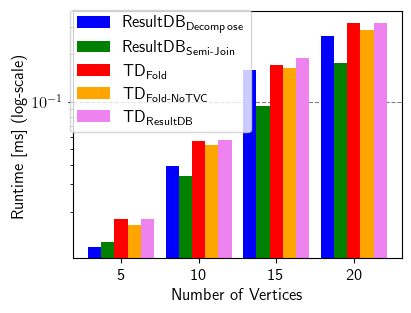

In [2]:
algorithm_times = {
    'ResultDB_Decompose': [],
    'ResultDB_SemiJoin': [],
    'TD_Fold': [],
    'TD_Fold-Greedy': [],
    'TD_ResultDB': []
}
# ensure that `queries` is sorted!
sizes = [5, 10, 15, 20]
data = pd.read_csv(f'./enumeration_time/{result_path}/cycle.csv')
data = (data.groupby(by=['commit', 'date', 'version', 'suite', 'benchmark', 'experiment', 'name', 'config', 'case',], as_index=False)
                .median()
                .drop(['commit', 'date', 'version', 'suite', 'benchmark', 'experiment', 'runid'], axis=1)
        )
num_queries = 0
for size in sizes:
    # Get Results for each query 
    size_data = data[data['case'] == size]

    for _, row in size_data.iterrows():
        algorithm = row['name']
        execution_time = row['time']
        if "TD_Fold_NoTVC" in algorithm:
            algorithm_times['TD_Fold-Greedy'].append(execution_time)
        elif "TD_Fold" in algorithm:
            algorithm_times['TD_Fold'].append(execution_time)
        elif "Heuristic" in algorithm:
            algorithm_times['ResultDB_SemiJoin'].append(execution_time)
        elif "Decompose" in algorithm:
            algorithm_times['ResultDB_Decompose'].append(execution_time)
        elif "TD_ResultDB" in algorithm:
            algorithm_times['TD_ResultDB'].append(execution_time)
        else:
            assert False, f"experiment name: {algorithm} does not match any of our algorithms"

for i in range(len(sizes)):
    print(algorithm_times['TD_Fold'][i] / algorithm_times['ResultDB_Decompose'][i])

x = np.arange(len(sizes))  
width = 0.17  
multiplier = -1
fig, ax = plt.subplots(layout='constrained', figsize=(4,3))
for algorithm, time in algorithm_times.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, time, width, label=alg_to_latex[algorithm], color=colors[algorithm])
    multiplier += 1

ax.set_ylabel('Runtime [ms] (log-scale)')
ax.set_xlabel('Number of Vertices')
ax.set_xticks(x + width, sizes)
ax.set_yscale('log')
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed')
fig.legend(bbox_to_anchor=(0.14, 1.02), loc='upper left')

fig.savefig(f'./enumeration_time/{result_path}/cycle_benchmark_results.pdf')

# Two-Vertex Cuts

{'ResultDB_Decompose': [0.014, 0.0675, 0.66, 23.1465], 'ResultDB_SemiJoin': [0.0135, 0.0305, 0.07, 0.2255], 'TD_Fold': [0.025, 0.0985, 0.7324999999999999, 23.502000000000002], 'TD_Fold-Greedy': [0.019, 0.082, 0.7004999999999999, 23.4165], 'TD_ResultDB': [0.025, 0.0955, 0.726, 23.5775]}
1.7857142857142858
1.4592592592592593
1.1098484848484846
1.01535869353898


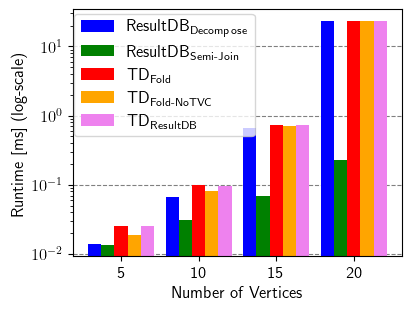

In [4]:
algorithm_times = {
    'ResultDB_Decompose': [],
    'ResultDB_SemiJoin': [],
    'TD_Fold': [],
    'TD_Fold-Greedy': [],
    'TD_ResultDB': []
}
# ensure that `queries` is sorted!
sizes = [5, 10, 15, 20]
data = pd.read_csv(f'./enumeration_time/{result_path}/tvc.csv')
data = (data.groupby(by=['commit', 'date', 'version', 'suite', 'benchmark', 'experiment', 'name', 'config', 'case',], as_index=False)
                .median()
                .drop(['commit', 'date', 'version', 'suite', 'benchmark', 'experiment', 'runid'], axis=1)
        )
num_queries = 0
for size in sizes:
    # Get Results for each query
    size_data = data[data['case'] == size]

    for _, row in size_data.iterrows():
        algorithm = row['name']
        execution_time = row['time']
        if "TD_Fold_NoTVC" in algorithm:
            algorithm_times['TD_Fold-Greedy'].append(execution_time)
        elif "TD_Fold" in algorithm:
            algorithm_times['TD_Fold'].append(execution_time)
        elif "Heuristic" in algorithm:
            algorithm_times['ResultDB_SemiJoin'].append(execution_time)
        elif "Decompose" in algorithm:
            algorithm_times['ResultDB_Decompose'].append(execution_time)
        elif "TD_ResultDB" in algorithm:
            algorithm_times['TD_ResultDB'].append(execution_time)
        else:
            assert False, f"experiment name: {algorithm} does not match any of our algorithms"

x = np.arange(len(sizes))
print(algorithm_times)
width = 0.17
multiplier = -1
fig, ax = plt.subplots(layout='constrained', figsize=(4,3))
for algorithm, time in algorithm_times.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, time, width, label=alg_to_latex[algorithm], color=colors[algorithm])
    multiplier += 1

for i in range(len(sizes)):
    print(algorithm_times['TD_Fold'][i] / algorithm_times['ResultDB_Decompose'][i])

ax.set_ylabel('Runtime [ms] (log-scale)')
ax.set_xlabel('Number of Vertices')
ax.set_xticks(x + width, sizes)
ax.set_yscale('log')
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed')
fig.legend(bbox_to_anchor=(0.15, 1.0), loc='upper left')

fig.savefig(f'./enumeration_time/{result_path}/tvc_benchmark_results.pdf')

# Synthetic Experiments

## Two-Vertex Cuts

{'ResultDB_Decompose': {'Execution': [1247.51, 2109.05, 3212.41, 4406.13], 'Optimization': []}, 'ResultDB_SemiJoin': {'Execution': [884.489, 1686.86, 2638.74, 3828.88], 'Optimization': []}, 'TD_Fold': {'Execution': [253.794, 440.33, 649.417, 1151.5], 'Optimization': []}, 'TD_Fold-Greedy': {'Execution': [326.981, 508.536, 736.333, 1236.55], 'Optimization': []}, 'TD_ResultDB': {'Execution': [253.992, 434.883, 664.29, 1155.62], 'Optimization': []}}


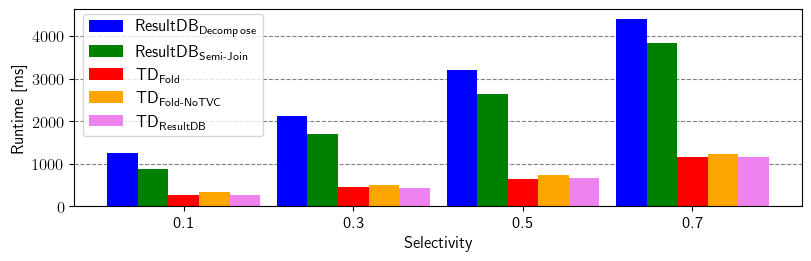

In [19]:
algorithm_times = {
    'ResultDB_Decompose': create_dict(),
    "ResultDB_SemiJoin": create_dict(),
    'TD_Fold': create_dict(),
    'TD_Fold-Greedy': create_dict(),
    "TD_ResultDB": create_dict(),
}
# ensure that `queries` is sorted!
queries = list(reversed([
    3,
    5,
    7,
    9,
]))
data = pd.read_csv(f'./synthetic/{result_path}/tvc_synthetic.csv')
data = (data.groupby(by=['commit', 'date', 'version', 'suite', 'benchmark', 'experiment', 'name', 'config', 'case',], as_index=False)
                .median()
                .drop(['commit', 'date', 'version', 'suite', 'benchmark', 'experiment', 'runid'], axis=1)
        )
num_queries = 0
for query in queries:
    # Get Results for each query 
    query_data = data[data['case'] == query]
    for _, row in query_data.iterrows():
        key = "Execution"
        if 'Optimization' in row['config']:
            key = "Optimization"
        algorithm = row['name']
        time = row['time']
        if "ResultDB-Heuristic" in algorithm:
            algorithm_times['ResultDB_SemiJoin'][key].append(time)
        elif "TD_Fold-NoTVC" in algorithm:
            algorithm_times['TD_Fold-Greedy'][key].append(time)
        elif "TD_Fold" in algorithm:
            algorithm_times['TD_Fold'][key].append(time)
        elif "TD_ResultDB" in algorithm:
            algorithm_times['TD_ResultDB'][key].append(time)
        elif "Decompose" in algorithm:
            algorithm_times['ResultDB_Decompose'][key].append(time)
        else:
            assert False, f"experiment name: {algorithm} does not match any of our algorithms"

print(algorithm_times)
x = np.arange(len(queries))  
width = 0.18  
multiplier = -1
fig, ax = plt.subplots(layout='constrained', figsize=(8,2.5))
for algorithm, times in algorithm_times.items():
    offset = width * multiplier
    ax.bar(x + offset, times["Execution"], width, label=alg_to_latex[algorithm],  color=colors[algorithm])
    multiplier += 1

ax.set_ylabel('Runtime [ms]')
ax.set_xlabel('Selectivity')
ax.set_xticks(x + width, list(reversed([0.7, 0.5, 0.3, 0.1])))
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed')
ax.legend(bbox_to_anchor=(0.00, 1.02), loc='upper left')

fig.savefig(f'./synthetic/{result_path}/tvc_synthetic_benchmark_results.pdf')

# Job Experiments

Max: 5.976959425520436
Min: 0.7532238199112614
Mean: 1.5607436287760343


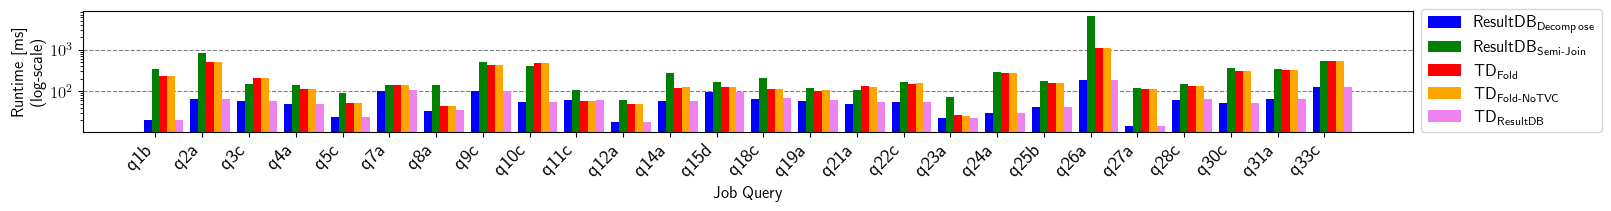

In [2]:
algorithm_times = {
    'ResultDB_Decompose': create_dict(),
    'ResultDB_SemiJoin': create_dict(),
    'TD_Fold': create_dict(),
    'TD_Fold-Greedy': create_dict(),
    'TD_ResultDB': create_dict(),
}


queries = [
    "q1b",
    "q2a",
    "q3c",
    "q4a",
    "q5c",
    "q7a",
    "q8a",
    "q9c",
    "q10c",
    "q11c",
    "q12a",
    "q14a",
    "q15d",
    "q18c",
    "q19a",
    "q21a",
    "q22c",
    "q23a",
    "q24a",
    "q25b",
    "q26a",
    "q27a",
    "q28c",
    "q30c",
    "q31a",
    "q33c"
]

data = pd.read_csv(f'./job/{result_path}/cyclic_results.csv')
data = (data.groupby(by=['commit', 'date', 'version', 'suite', 'benchmark', 'experiment', 'name', 'config', 'case',], as_index=False)
                .median()
                .drop(['commit', 'date', 'version', 'suite', 'benchmark', 'case', 'runid'], axis=1)
        )
for query in queries:
    # Get Results for each query
    query_data = data[data['experiment'] == query]
    for _, row in query_data.iterrows():
        key = "Execution"
        if 'Optimization' in row['config']:
            key = "Optimization"
        algorithm = row['name']
        time = row['time']
        if "Decompose" in algorithm:
            algorithm_times['ResultDB_Decompose'][key].append(time)
        elif "Heuristic" in algorithm or "SemiJoin" in algorithm:
            algorithm_times['ResultDB_SemiJoin'][key].append(time)
        elif 'TD_Fold_NoTVC' in algorithm:
            algorithm_times['TD_Fold-Greedy'][key].append(time)
        elif "Fold" in algorithm or "Root" in algorithm:
            algorithm_times['TD_Fold'][key].append(time)
        elif "TD_ResultDB" in algorithm or "RESULTDB" in algorithm:
            algorithm_times['TD_ResultDB'][key].append(time)
        else:
            assert False, f"experiment name: {algorithm} does not match any of our algorithms"
all_ = []
for i in range(len(queries)):
    all_.append(1 / (algorithm_times['TD_Fold']['Execution'][i] / algorithm_times['ResultDB_SemiJoin']['Execution'][i]))
print(f"Max: {max(all_)}")
print(f"Min: {min(all_)}")
print(f"Mean: {statistics.mean(all_)}")
x = np.arange(len(queries))  
width = 0.17  
multiplier = -1
fig, ax = plt.subplots(layout='constrained', figsize=(16,2))
for algorithm, times in algorithm_times.items():
    offset = width * multiplier
    ax.bar(x + offset, times["Execution"], width, label=alg_to_latex[algorithm], color=colors[algorithm])
    multiplier += 1

ax.set_ylabel('Runtime [ms]\n(log-scale)')
ax.set_xlabel('Job Query')
ax.set_xticks(x, queries)
ax.set_yscale('log')
ax.set_xticklabels(queries, rotation=45, ha="right", fontsize=14)
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed')
ax.legend(bbox_to_anchor=(1.00, 1.08), loc='upper left')

fig.savefig(f'./job/{result_path}/job_cyclic_benchmark_results.pdf')

Max: 1.462359478997484
Min: 0.9713785406188634
Mean: 1.1299527265982452


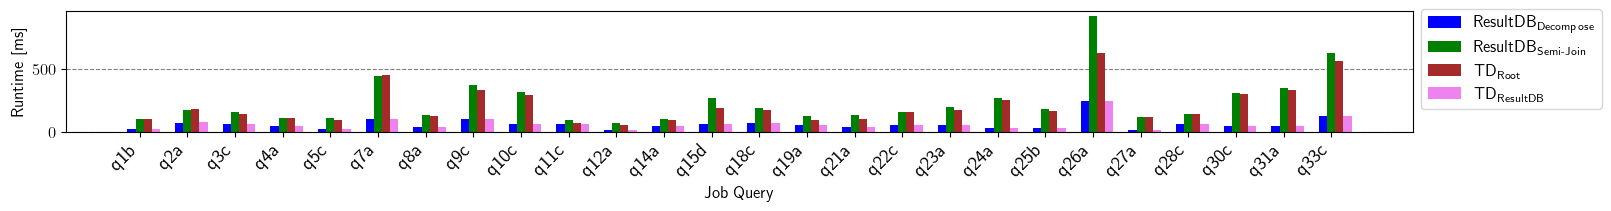

In [3]:
algorithm_times = {
    'ResultDB_Decompose': create_dict(),
    'ResultDB_SemiJoin': create_dict(),
    'TD_Root': create_dict(),
    'TD_ResultDB': create_dict(),
}


queries = [
    "q1b",
    "q2a",
    "q3c",
    "q4a",
    "q5c",
    "q7a",
    "q8a",
    "q9c",
    "q10c",
    "q11c",
    "q12a",
    "q14a",
    "q15d",
    "q18c",
    "q19a",
    "q21a",
    "q22c",
    "q23a",
    "q24a",
    "q25b",
    "q26a",
    "q27a",
    "q28c",
    "q30c",
    "q31a",
    "q33c"
]

data = pd.read_csv(f'./job/{result_path}/acyclic_results.csv')
data = (data.groupby(by=['commit', 'date', 'version', 'suite', 'benchmark', 'experiment', 'name', 'config', 'case',], as_index=False)
                .median()
                .drop(['commit', 'date', 'version', 'suite', 'benchmark', 'case', 'runid'], axis=1)
        )
for query in queries:
    # Get Results for each query
    query_data = data[data['experiment'] == query]
    for _, row in query_data.iterrows():
        key = "Execution"
        if 'Optimization' in row['config']:
            key = "Optimization"
        algorithm = row['name']
        time = row['time']
        if "Decompose" in algorithm:
            algorithm_times['ResultDB_Decompose'][key].append(time)
        elif "SemiJoin" in algorithm:
            algorithm_times['ResultDB_SemiJoin'][key].append(time)
        elif "Root" in algorithm:
            algorithm_times['TD_Root'][key].append(time)
        elif "RESULTDB" in algorithm:
            algorithm_times['TD_ResultDB'][key].append(time)
        else:
            assert False, f"experiment name: {algorithm} does not match any of our algorithms"
all_ = []
for i in range(len(queries)):
    all_.append(1 / (algorithm_times['TD_Root']['Execution'][i] / algorithm_times['ResultDB_SemiJoin']['Execution'][i]))
print(f"Max: {max(all_)}")
print(f"Min: {min(all_)}")
print(f"Mean: {statistics.mean(all_)}")
x = np.arange(len(queries))
width = 0.17
multiplier = -1
fig, ax = plt.subplots(layout='constrained', figsize=(16,2))
for algorithm, times in algorithm_times.items():
    offset = width * multiplier
    ax.bar(x + offset, times["Execution"], width, label=alg_to_latex[algorithm], color=colors[algorithm])
    multiplier += 1

ax.set_ylabel('Runtime [ms]')
ax.set_xlabel('Job Query')
ax.set_xticks(x, queries)
#ax.set_yscale('log')
ax.set_xticklabels(queries, rotation=45, ha="right", fontsize=14)
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed')
ax.legend(bbox_to_anchor=(1.00, 1.08), loc='upper left')

fig.savefig(f'./job/{result_path}/job_benchmark_results.pdf')

1.0647141901434622
1.3830773453144534
1.3396688094321179
1.1851928038695954
1.1392767179464567
1.1295208695765915
0.9851593768896312
1.3545627040341306
1.164250766170224
1.2328169159124456
1.0879688605803255
1.5808690914556247
Max: 1.5808690914556247
Min: 0.9851593768896312
Mean: 1.2205898709437548


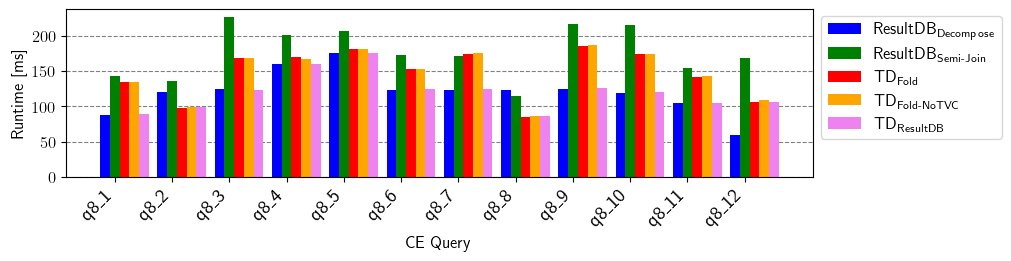

In [3]:
algorithm_times = {
    'ResultDB_Decompose': create_dict(),
    'ResultDB_SemiJoin': create_dict(),
    'TD_Fold': create_dict(),
    'TD_Fold-Greedy': create_dict(),
    'TD_ResultDB': create_dict(),
}


queries = [
        "q8_1",
        "q8_2", "q8_3",
        "q8_4", "q8_5", "q8_6", "q8_7", "q8_8", "q8_9", "q8_10", "q8_11", "q8_12"
]

data = pd.read_csv(f'./ce/{result_path}/results.csv')
data = (data.groupby(by=['commit', 'date', 'version', 'suite', 'benchmark', 'experiment', 'name', 'config', 'case',], as_index=False)
                .median()
                .drop(['commit', 'date', 'version', 'suite', 'benchmark', 'case', 'runid'], axis=1)
        )
for query in queries:
    # Get Results for each query
    query_data = data[data['experiment'] == query]
    for _, row in query_data.iterrows():
        key = "Execution"
        if 'Optimization' in row['config']:
            key = "Optimization"
        algorithm = row['name']
        time = row['time']
        if "Decompose" in algorithm:
            algorithm_times['ResultDB_Decompose'][key].append(time)
        elif "Heuristic" in algorithm or "SemiJoin" in algorithm:
            algorithm_times['ResultDB_SemiJoin'][key].append(time)
        elif 'TD_Fold_NoTVC' in algorithm:
            algorithm_times['TD_Fold-Greedy'][key].append(time)
        elif "Fold" in algorithm or "Root" in algorithm:
            algorithm_times['TD_Fold'][key].append(time)
        elif "TD_ResultDB" in algorithm or "RESULTDB" in algorithm:
            algorithm_times['TD_ResultDB'][key].append(time)
        else:
            assert False, f"experiment name: {algorithm} does not match any of our algorithms"
all_ = []
for i in range(len(queries)):
    print(1 / (algorithm_times['TD_Fold']['Execution'][i] / algorithm_times['ResultDB_SemiJoin']['Execution'][i]))
    all_.append(1 / (algorithm_times['TD_Fold']['Execution'][i] / algorithm_times['ResultDB_SemiJoin']['Execution'][i]))
print(f"Max: {max(all_)}")
print(f"Min: {min(all_)}")
print(f"Mean: {statistics.mean(all_)}")
x = np.arange(len(queries))
width = 0.17
multiplier = -1
fig, ax = plt.subplots(layout='constrained', figsize=(10,2.5))
for algorithm, times in algorithm_times.items():
    offset = width * multiplier
    ax.bar(x + offset, times["Execution"], width, label=alg_to_latex[algorithm], color=colors[algorithm])
    multiplier += 1

ax.set_ylabel('Runtime [ms]')
ax.set_xlabel('CE Query')
ax.set_xticks(x, queries)
ax.set_xticklabels(queries, rotation=45, ha="right", fontsize=14)
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed')
ax.legend(bbox_to_anchor=(1.0, 1.01), loc='upper left')

fig.savefig(f'./ce/ce_benchmark_results.pdf')